[2026-05-26 15:00:54 | +00:00:00] 元グラフ生成開始
[2026-05-26 15:00:54 | +00:00:00] 元グラフ生成完了: nodes=100, edges=371
[2026-05-26 15:00:54 | +00:00:00] ==============================
[2026-05-26 15:00:54 | +00:00:00] 疎化実行開始
[2026-05-26 15:00:54 | +00:00:00] ==============================
[2026-05-26 15:00:54 | +00:00:00] Original: nodes=100, edges=371, avg_degree=7.42, components=1, largest_cc=100
[2026-05-26 15:00:54 | +00:00:00] Random疎化開始
[2026-05-26 15:00:54 | +00:00:00] Random疎化完了: edges=111
[2026-05-26 15:00:54 | +00:00:00] Random: nodes=100, edges=111, avg_degree=2.22, components=8, largest_cc=92
[2026-05-26 15:00:54 | +00:00:00] Degree疎化開始
[2026-05-26 15:00:54 | +00:00:00] Degree疎化完了: edges=111
[2026-05-26 15:00:54 | +00:00:00] Degree: nodes=100, edges=111, avg_degree=2.22, components=45, largest_cc=56
[2026-05-26 15:00:54 | +00:00:00] PageRank疎化開始
[2026-05-26 15:00:54 | +00:00:00] PageRank疎化完了: edges=111
[2026-05-26 15:00:54 | +00:00:00] PageRank: nodes=100, edges=111, avg_degree=2.22, 

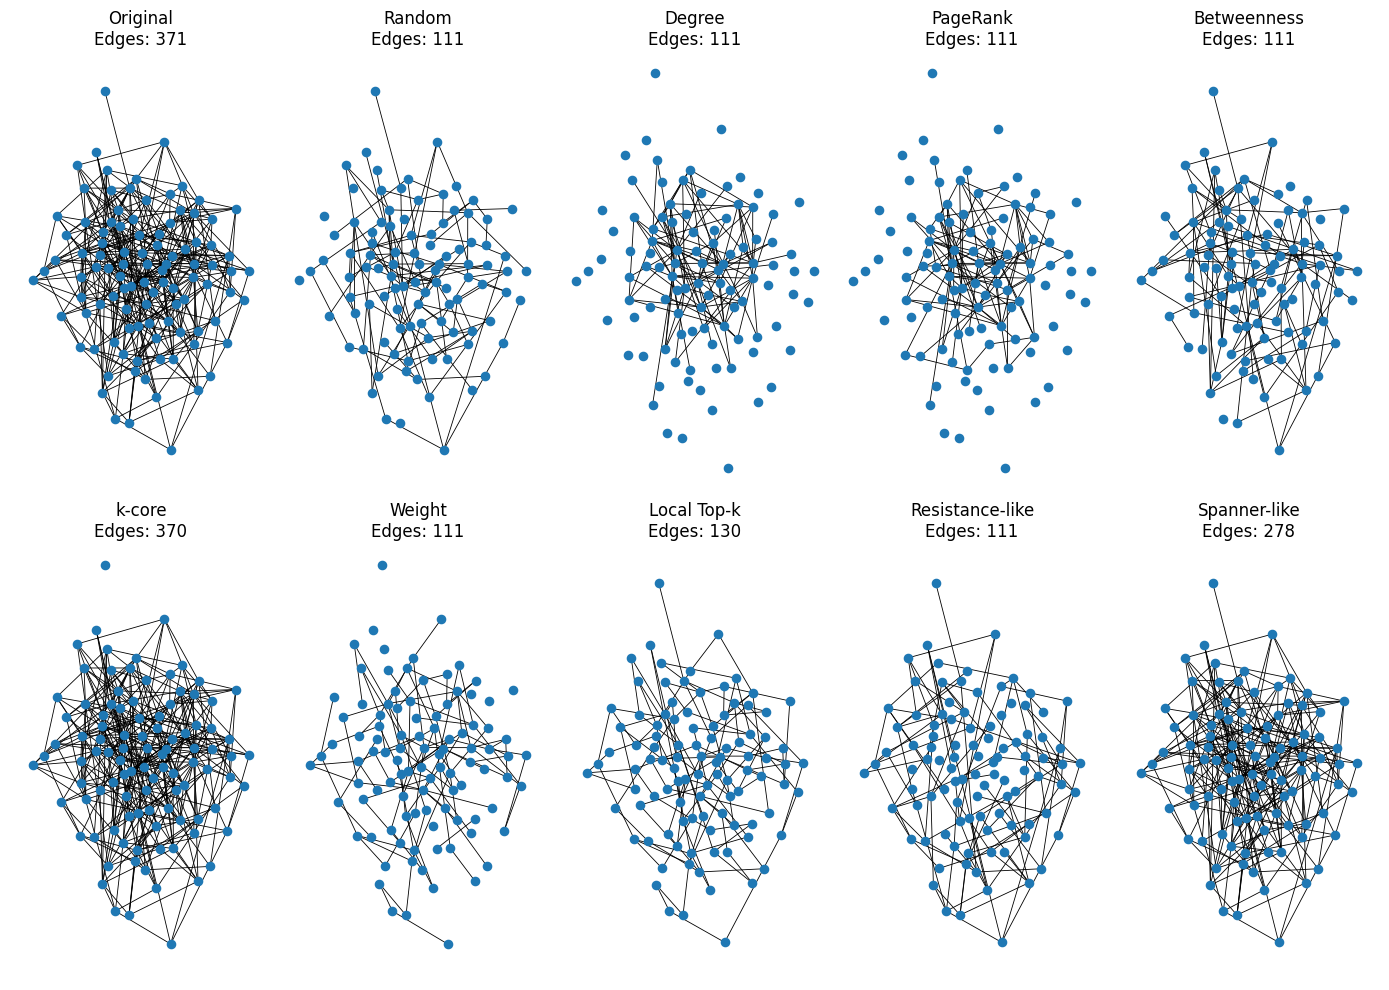

[2026-05-26 15:01:01 | +00:00:06] グラフ描画完了
[2026-05-26 15:01:01 | +00:00:06] TSP経路描画開始


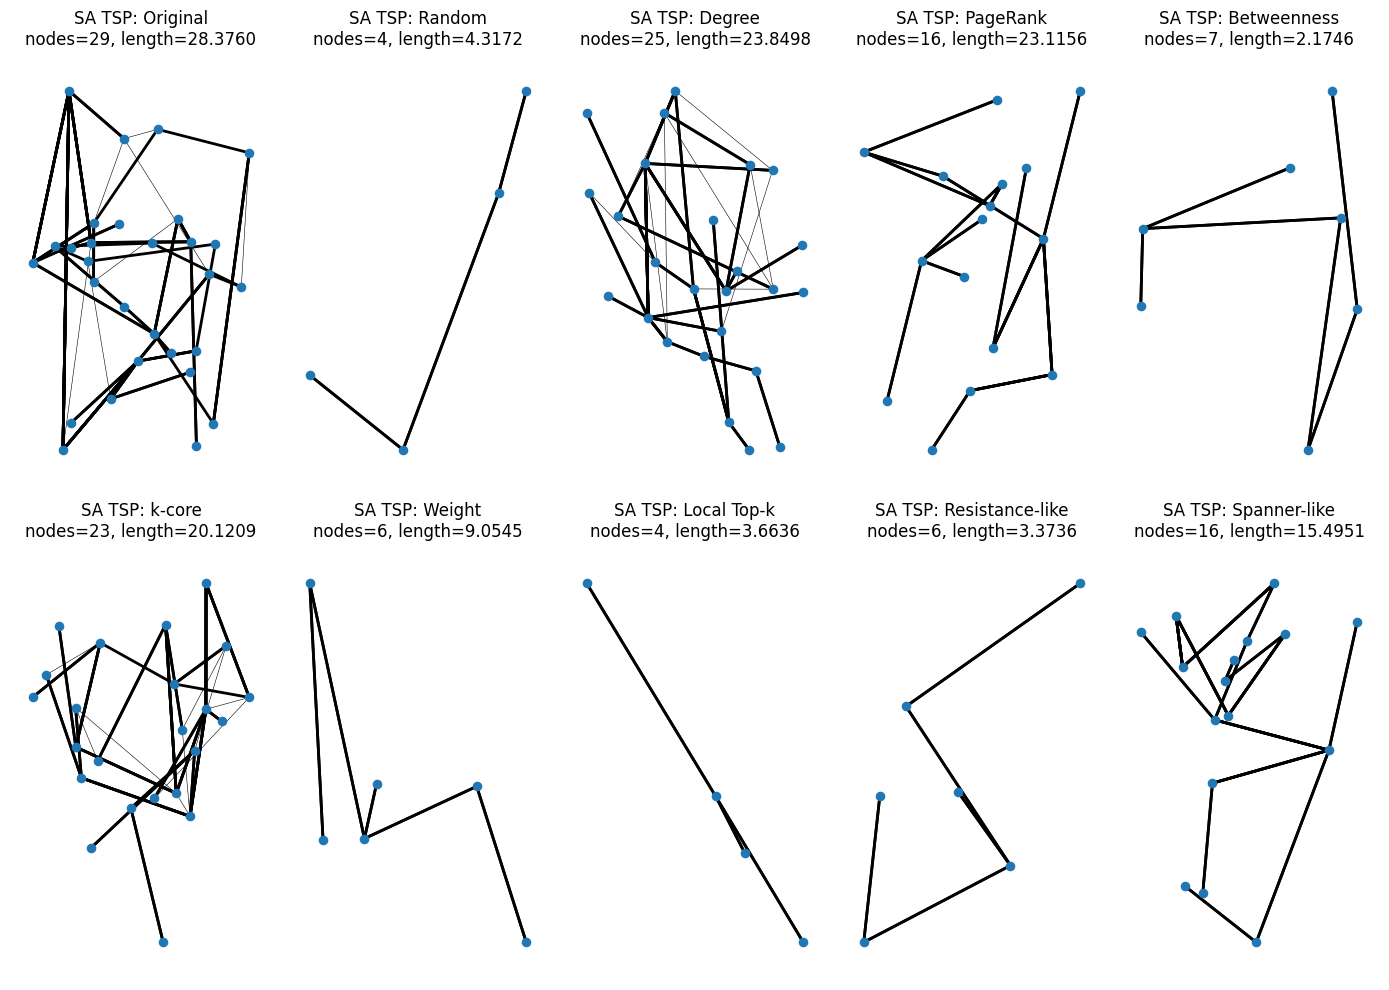

[2026-05-26 15:01:03 | +00:00:08] TSP経路描画完了
[2026-05-26 15:01:03 | +00:00:08] TSP結果プロット開始


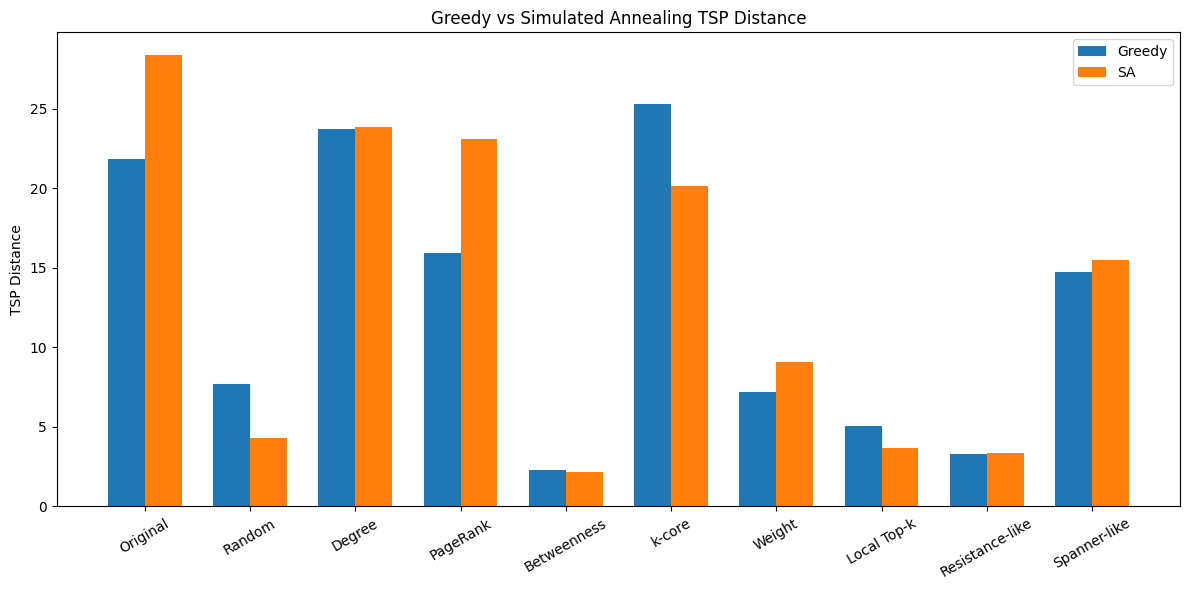

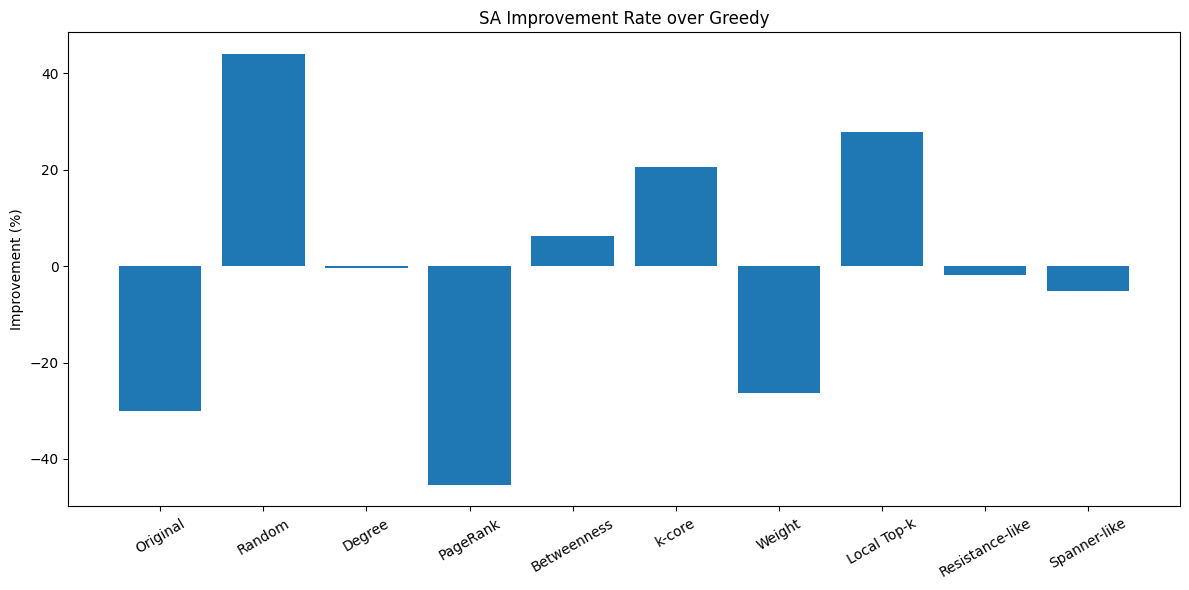

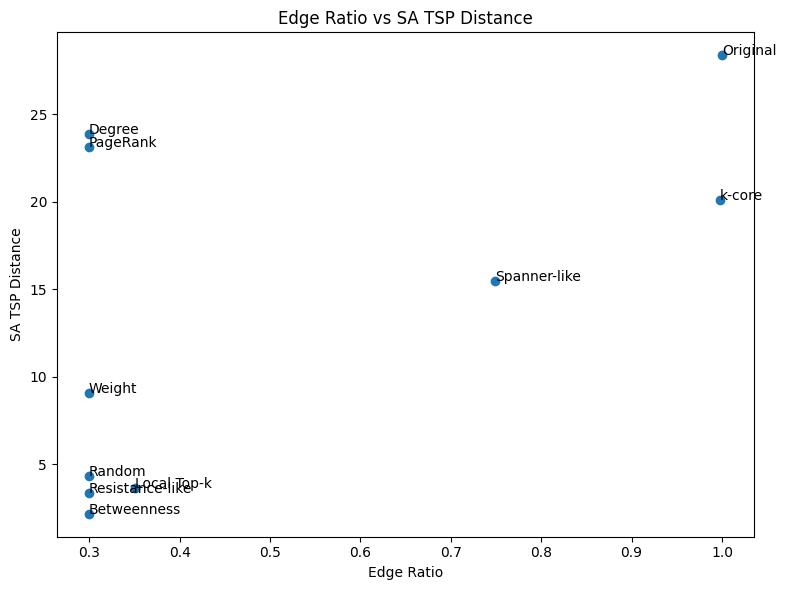

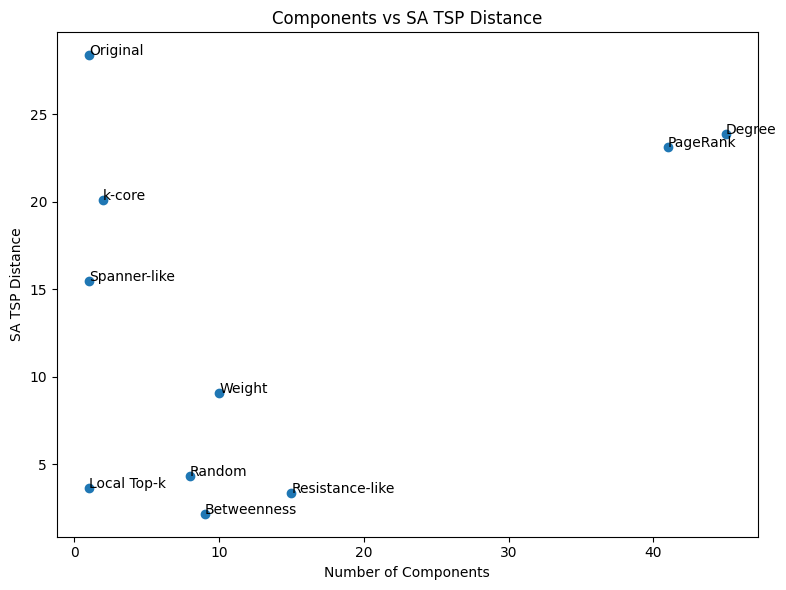

[2026-05-26 15:01:05 | +00:00:10] TSP結果プロット完了
[2026-05-26 15:01:05 | +00:00:10] 全処理完了


In [6]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
import time
from datetime import datetime

from networkx.algorithms.approximation import (
    greedy_tsp,
    simulated_annealing_tsp
)

# =========================
# パラメータ
# =========================
NUM_NODES = 100
EDGE_PROB = 0.08
SPARSIFY_RATIO = 0.3
SEED = 42

K_CORE = 2
LOCAL_TOP_K = 2
SPANNER_STRETCH = 2

MAX_TSP_NODES = 30

SA_TEMP = 100
SA_MAX_ITERATIONS = 300
SA_N_INNER = 50
SA_TRIALS = 1
SA_MOVE = "1-1"

DRAW_GRAPHS = True
DRAW_TSP_PATHS = True
DRAW_TSP_SUMMARY_PLOTS = True

random.seed(SEED)
np.random.seed(SEED)

START_TIME = time.time()

# =========================
# ログ関数
# =========================
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def elapsed_str():
    sec = int(time.time() - START_TIME)
    h = sec // 3600
    m = (sec % 3600) // 60
    s = sec % 60
    return f"+{h:02d}:{m:02d}:{s:02d}"


def log(msg):
    print(f"[{now_str()} | {elapsed_str()}] {msg}", flush=True)


# =========================
# 元グラフ生成
# =========================
log("元グラフ生成開始")

G = nx.erdos_renyi_graph(
    n=NUM_NODES,
    p=EDGE_PROB,
    seed=SEED
)

for u, v in G.edges():
    G[u][v]["weight"] = random.random()

log(f"元グラフ生成完了: nodes={G.number_of_nodes()}, edges={G.number_of_edges()}")


# =========================
# 共通関数
# =========================
def make_graph_from_edges(G, selected_edges):
    H = nx.Graph()
    H.add_nodes_from(G.nodes())

    for u, v in selected_edges:
        if G.has_edge(u, v):
            H.add_edge(u, v, **G[u][v])
        else:
            H.add_edge(u, v, weight=1.0)

    return H


def keep_top_edges_by_score(G, edge_scores, ratio):
    edges = list(G.edges())
    num_keep = max(1, int(len(edges) * ratio))

    sorted_edges = sorted(
        edges,
        key=lambda e: edge_scores.get(tuple(sorted(e)), 0),
        reverse=True
    )

    return make_graph_from_edges(G, sorted_edges[:num_keep])


def graph_stats(H):
    avg_degree = sum(dict(H.degree()).values()) / H.number_of_nodes()

    if H.number_of_edges() > 0:
        components = nx.number_connected_components(H)
        largest_cc_size = len(max(nx.connected_components(H), key=len))
    else:
        components = H.number_of_nodes()
        largest_cc_size = 1

    return avg_degree, components, largest_cc_size


def print_graph_info(name, H):
    avg_degree, components, largest_cc_size = graph_stats(H)

    log(
        f"{name}: nodes={H.number_of_nodes()}, "
        f"edges={H.number_of_edges()}, "
        f"avg_degree={avg_degree:.2f}, "
        f"components={components}, "
        f"largest_cc={largest_cc_size}"
    )


# =========================
# 疎化手法
# =========================
def random_sparsification(G, ratio):
    log("Random疎化開始")
    edges = list(G.edges())
    num_keep = max(1, int(len(edges) * ratio))
    sampled_edges = random.sample(edges, num_keep)
    H = make_graph_from_edges(G, sampled_edges)
    log(f"Random疎化完了: edges={H.number_of_edges()}")
    return H


def degree_based_sparsification(G, ratio):
    log("Degree疎化開始")
    deg = dict(G.degree())

    edge_scores = {}
    for u, v in G.edges():
        edge_scores[tuple(sorted((u, v)))] = deg[u] + deg[v]

    H = keep_top_edges_by_score(G, edge_scores, ratio)
    log(f"Degree疎化完了: edges={H.number_of_edges()}")
    return H


def pagerank_based_sparsification(G, ratio):
    log("PageRank疎化開始")
    pr = nx.pagerank(G, weight="weight")

    edge_scores = {}
    for u, v in G.edges():
        edge_scores[tuple(sorted((u, v)))] = pr[u] + pr[v]

    H = keep_top_edges_by_score(G, edge_scores, ratio)
    log(f"PageRank疎化完了: edges={H.number_of_edges()}")
    return H


def edge_betweenness_sparsification(G, ratio):
    log("Betweenness疎化開始")
    eb = nx.edge_betweenness_centrality(G, weight="weight")

    edge_scores = {}
    for e, score in eb.items():
        edge_scores[tuple(sorted(e))] = score

    H = keep_top_edges_by_score(G, edge_scores, ratio)
    log(f"Betweenness疎化完了: edges={H.number_of_edges()}")
    return H


def k_core_sparsification(G, k):
    log(f"k-core疎化開始: k={k}")
    core = nx.k_core(G, k=k)

    H = nx.Graph()
    H.add_nodes_from(G.nodes())

    for u, v in core.edges():
        H.add_edge(u, v, **G[u][v])

    log(f"k-core疎化完了: edges={H.number_of_edges()}")
    return H


def weight_threshold_sparsification(G, ratio):
    log("Weight疎化開始")
    edges = list(G.edges(data=True))
    num_keep = max(1, int(len(edges) * ratio))

    sorted_edges = sorted(
        edges,
        key=lambda x: x[2].get("weight", 0),
        reverse=True
    )

    selected_edges = [(u, v) for u, v, _ in sorted_edges[:num_keep]]
    H = make_graph_from_edges(G, selected_edges)

    log(f"Weight疎化完了: edges={H.number_of_edges()}")
    return H


def local_top_k_sparsification(G, k):
    log(f"Local Top-k疎化開始: k={k}")
    selected_edges = set()

    for node in G.nodes():
        neighbors = list(G.neighbors(node))

        scored_neighbors = []
        for nbr in neighbors:
            score = G[node][nbr].get("weight", 1.0)
            scored_neighbors.append((nbr, score))

        scored_neighbors.sort(key=lambda x: x[1], reverse=True)

        for nbr, _ in scored_neighbors[:k]:
            selected_edges.add(tuple(sorted((node, nbr))))

    H = make_graph_from_edges(G, list(selected_edges))
    log(f"Local Top-k疎化完了: edges={H.number_of_edges()}")
    return H


def effective_resistance_like_sparsification(G, ratio):
    log("Resistance-like疎化開始")
    deg = dict(G.degree())

    edge_scores = {}
    for u, v in G.edges():
        score = 1 / max(1, deg[u]) + 1 / max(1, deg[v])
        edge_scores[tuple(sorted((u, v)))] = score

    H = keep_top_edges_by_score(G, edge_scores, ratio)
    log(f"Resistance-like疎化完了: edges={H.number_of_edges()}")
    return H


def spanner_like_sparsification(G, stretch=2):
    log(f"Spanner-like疎化開始: stretch={stretch}")

    H = nx.Graph()
    H.add_nodes_from(G.nodes())

    edges = list(G.edges(data=True))
    random.shuffle(edges)

    for u, v, data in edges:
        if not nx.has_path(H, u, v):
            H.add_edge(u, v, **data)
        else:
            try:
                dist = nx.shortest_path_length(H, u, v, weight="weight")
                direct_weight = data.get("weight", 1.0)

                if dist > stretch * direct_weight:
                    H.add_edge(u, v, **data)

            except nx.NetworkXNoPath:
                H.add_edge(u, v, **data)

    log(f"Spanner-like疎化完了: edges={H.number_of_edges()}")
    return H


# =========================
# TSP用関数
# =========================
def get_largest_connected_subgraph(H, name):
    log(f"{name}: 連結成分確認開始")

    if H.number_of_edges() == 0:
        log(f"{name}: エッジなし。TSP対象外")
        return None

    if nx.is_connected(H):
        T = H.copy()
        log(f"{name}: 連結グラフ")
    else:
        largest_cc = max(nx.connected_components(H), key=len)
        T = H.subgraph(largest_cc).copy()
        log(
            f"{name}: 非連結。最大連結成分を使用: "
            f"nodes={T.number_of_nodes()}, edges={T.number_of_edges()}"
        )

    if T.number_of_nodes() > MAX_TSP_NODES:
        sampled_nodes = random.sample(list(T.nodes()), MAX_TSP_NODES)
        T = T.subgraph(sampled_nodes).copy()

        if T.number_of_edges() > 0:
            largest_cc = max(nx.connected_components(T), key=len)
            T = T.subgraph(largest_cc).copy()

        log(
            f"{name}: TSP対象ノード数を制限: "
            f"nodes={T.number_of_nodes()}, MAX_TSP_NODES={MAX_TSP_NODES}"
        )

    if T.number_of_nodes() < 3:
        log(f"{name}: TSP対象ノードが少なすぎる")
        return None

    return T


def make_metric_complete_graph(T, name):
    log(f"{name}: TSP用完全グラフ作成開始")

    K = nx.Graph()
    K.add_nodes_from(T.nodes())

    lengths = dict(nx.all_pairs_dijkstra_path_length(T, weight="weight"))
    nodes = list(T.nodes())

    for i, u in enumerate(nodes):
        for v in nodes[i + 1:]:
            K.add_edge(u, v, weight=lengths[u][v])

    log(
        f"{name}: TSP用完全グラフ作成完了: "
        f"nodes={K.number_of_nodes()}, edges={K.number_of_edges()}"
    )

    return K


def compute_cycle_length(K, cycle):
    total = 0.0

    for u, v in zip(cycle[:-1], cycle[1:]):
        total += K[u][v]["weight"]

    return total


def make_random_cycle(K):
    nodes = list(K.nodes())
    random.shuffle(nodes)
    nodes.append(nodes[0])
    return nodes


def cycle_to_sparse_edges(T, cycle):
    tsp_edges = []

    for u, v in zip(cycle[:-1], cycle[1:]):
        path = nx.shortest_path(T, u, v, weight="weight")
        path_edges = list(zip(path[:-1], path[1:]))
        tsp_edges.extend(path_edges)

    return tsp_edges


def cycle_preview(cycle, max_items=20):
    if cycle is None:
        return "None"

    preview = cycle[:max_items]

    if len(cycle) > max_items:
        return " -> ".join(map(str, preview)) + " -> ..."
    else:
        return " -> ".join(map(str, cycle))


def solve_tsp_greedy(name, H):
    log(f"{name}: Greedy TSP開始")

    T = get_largest_connected_subgraph(H, name)

    if T is None:
        log(f"{name}: Greedy TSPスキップ")
        return None

    try:
        K = make_metric_complete_graph(T, name)

        t0 = time.time()
        cycle = greedy_tsp(K, weight="weight")
        length = compute_cycle_length(K, cycle)

        log(
            f"{name}: Greedy TSP完了: "
            f"length={length:.4f}, time={time.time() - t0:.2f}s"
        )

        log(f"{name}: Greedy cycle: {cycle_preview(cycle)}")

        return {
            "name": name,
            "method": "Greedy",
            "nodes": T.number_of_nodes(),
            "edges": T.number_of_edges(),
            "components": nx.number_connected_components(H),
            "used_largest_component": not nx.is_connected(H),
            "tsp_length": length,
            "cycle": cycle,
            "subgraph": T,
            "metric_graph": K
        }

    except Exception as e:
        log(f"[Greedy TSP failed] {name}: {e}")
        return None


def solve_tsp_simulated_annealing(name, H):
    log(f"{name}: SA TSP開始")

    T = get_largest_connected_subgraph(H, name)

    if T is None:
        log(f"{name}: SA TSPスキップ")
        return None

    try:
        K = make_metric_complete_graph(T, name)

        best_cycle = None
        best_length = float("inf")

        for trial in range(1, SA_TRIALS + 1):
            log(
                f"{name}: SA trial {trial}/{SA_TRIALS} 開始 "
                f"temp={SA_TEMP}, max_iter={SA_MAX_ITERATIONS}, "
                f"N_inner={SA_N_INNER}, move={SA_MOVE}"
            )

            init_cycle = make_random_cycle(K)
            init_length = compute_cycle_length(K, init_cycle)

            log(f"{name}: SA trial {trial} 初期解 length={init_length:.4f}")

            t0 = time.time()

            cycle = simulated_annealing_tsp(
                K,
                init_cycle=init_cycle,
                weight="weight",
                source=init_cycle[0],
                temp=SA_TEMP,
                move=SA_MOVE,
                max_iterations=SA_MAX_ITERATIONS,
                N_inner=SA_N_INNER
            )

            length = compute_cycle_length(K, cycle)
            elapsed = time.time() - t0

            if length < best_length:
                best_length = length
                best_cycle = cycle
                updated = "BEST更新"
            else:
                updated = "BEST更新なし"

            trial_improvement = (init_length - length) / init_length * 100

            log(
                f"{name}: SA trial {trial}/{SA_TRIALS} 完了 "
                f"init={init_length:.4f}, final={length:.4f}, "
                f"trial_improvement={trial_improvement:.2f}%, "
                f"best={best_length:.4f}, time={elapsed:.2f}s, {updated}"
            )

        log(f"{name}: SA TSP完了 best_length={best_length:.4f}")
        log(f"{name}: SA cycle: {cycle_preview(best_cycle)}")

        return {
            "name": name,
            "method": "SA",
            "nodes": T.number_of_nodes(),
            "edges": T.number_of_edges(),
            "components": nx.number_connected_components(H),
            "used_largest_component": not nx.is_connected(H),
            "tsp_length": best_length,
            "cycle": best_cycle,
            "subgraph": T,
            "metric_graph": K
        }

    except Exception as e:
        log(f"[SA TSP failed] {name}: {e}")
        return None


# =========================
# 疎化実行
# =========================
log("==============================")
log("疎化実行開始")
log("==============================")

graphs = {}

graphs["Original"] = G
print_graph_info("Original", graphs["Original"])

graphs["Random"] = random_sparsification(G, SPARSIFY_RATIO)
print_graph_info("Random", graphs["Random"])

graphs["Degree"] = degree_based_sparsification(G, SPARSIFY_RATIO)
print_graph_info("Degree", graphs["Degree"])

graphs["PageRank"] = pagerank_based_sparsification(G, SPARSIFY_RATIO)
print_graph_info("PageRank", graphs["PageRank"])

graphs["Betweenness"] = edge_betweenness_sparsification(G, SPARSIFY_RATIO)
print_graph_info("Betweenness", graphs["Betweenness"])

graphs["k-core"] = k_core_sparsification(G, K_CORE)
print_graph_info("k-core", graphs["k-core"])

graphs["Weight"] = weight_threshold_sparsification(G, SPARSIFY_RATIO)
print_graph_info("Weight", graphs["Weight"])

graphs["Local Top-k"] = local_top_k_sparsification(G, LOCAL_TOP_K)
print_graph_info("Local Top-k", graphs["Local Top-k"])

graphs["Resistance-like"] = effective_resistance_like_sparsification(G, SPARSIFY_RATIO)
print_graph_info("Resistance-like", graphs["Resistance-like"])

graphs["Spanner-like"] = spanner_like_sparsification(G, SPANNER_STRETCH)
print_graph_info("Spanner-like", graphs["Spanner-like"])

log("疎化実行完了")

# =========================
# TSP実行
# =========================
log("==============================")
log("TSP Results")
log("==============================")

tsp_results = {}

total_graphs = len(graphs)

for idx, (name, H) in enumerate(graphs.items(), start=1):
    log("--------------------------------------------------")
    log(f"[{idx}/{total_graphs}] {name}: TSP処理開始")

    greedy_result = solve_tsp_greedy(name, H)
    sa_result = solve_tsp_simulated_annealing(name, H)

    tsp_results[(name, "Greedy")] = greedy_result
    tsp_results[(name, "SA")] = sa_result

    greedy_len = None if greedy_result is None else greedy_result["tsp_length"]
    sa_len = None if sa_result is None else sa_result["tsp_length"]

    if greedy_len is None and sa_len is None:
        log(f"{name:16s}: TSP failed or too small")
    else:
        base_result = greedy_result if greedy_result is not None else sa_result

        used = (
            "largest component"
            if base_result["used_largest_component"]
            else "all nodes"
        )

        log(
            f"{name:16s} "
            f"nodes={base_result['nodes']:3d} "
            f"edges={base_result['edges']:4d} "
            f"components={base_result['components']:3d} "
            f"greedy={greedy_len if greedy_len is not None else 'NA'} "
            f"SA={sa_len if sa_len is not None else 'NA'} "
            f"used={used}"
        )

    log(f"[{idx}/{total_graphs}] {name}: TSP処理完了")

# =========================
# 改善率表示
# =========================
log("==============================")
log("TSP Improvement Summary")
log("==============================")

summary_names = []
summary_greedy = []
summary_sa = []
summary_improvement = []
summary_edge_ratio = []
summary_sa_nodes = []
summary_components = []

for name in graphs.keys():
    greedy_result = tsp_results.get((name, "Greedy"))
    sa_result = tsp_results.get((name, "SA"))

    if greedy_result is None or sa_result is None:
        log(f"{name:16s}: skipped")
        continue

    greedy_len = greedy_result["tsp_length"]
    sa_len = sa_result["tsp_length"]
    improvement = (greedy_len - sa_len) / greedy_len * 100
    edge_ratio = graphs[name].number_of_edges() / G.number_of_edges()

    summary_names.append(name)
    summary_greedy.append(greedy_len)
    summary_sa.append(sa_len)
    summary_improvement.append(improvement)
    summary_edge_ratio.append(edge_ratio)
    summary_sa_nodes.append(sa_result["nodes"])
    summary_components.append(sa_result["components"])

    log(
        f"{name:16s} "
        f"greedy={greedy_len:.4f} "
        f"SA={sa_len:.4f} "
        f"improvement={improvement:.2f}% "
        f"edge_ratio={edge_ratio:.2f}"
    )

# =========================
# グラフ描画
# =========================
if DRAW_GRAPHS:
    log("グラフ描画開始")

    pos = nx.spring_layout(G, seed=SEED)

    num_graphs = len(graphs)
    cols = 5
    rows = int(np.ceil(num_graphs / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 5))
    axes = axes.flatten()

    for ax, (name, H) in zip(axes, graphs.items()):
        nx.draw(
            H,
            pos,
            ax=ax,
            node_size=35,
            width=0.6,
            with_labels=False
        )

        ax.set_title(
            f"{name}\n"
            f"Edges: {H.number_of_edges()}"
        )

    for i in range(len(graphs), len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

    log("グラフ描画完了")

# =========================
# TSP経路描画
# =========================
if DRAW_TSP_PATHS:
    log("TSP経路描画開始")

    pos = nx.spring_layout(G, seed=SEED)

    valid_sa_results = {
        name: result
        for (name, method), result in tsp_results.items()
        if method == "SA" and result is not None
    }

    num_tsp = len(valid_sa_results)

    if num_tsp > 0:
        cols = 5
        rows = int(np.ceil(num_tsp / cols))

        fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 5))

        if num_tsp == 1:
            axes = np.array([axes])

        axes = axes.flatten()

        for ax, (name, result) in zip(axes, valid_sa_results.items()):
            T = result["subgraph"]
            cycle = result["cycle"]

            tsp_edges = cycle_to_sparse_edges(T, cycle)

            nx.draw(
                T,
                pos,
                ax=ax,
                node_size=35,
                width=0.4,
                with_labels=False
            )

            nx.draw_networkx_edges(
                T,
                pos,
                edgelist=tsp_edges,
                ax=ax,
                width=2.0
            )

            ax.set_title(
                f"SA TSP: {name}\n"
                f"nodes={result['nodes']}, "
                f"length={result['tsp_length']:.4f}"
            )

        for i in range(num_tsp, len(axes)):
            axes[i].axis("off")

        plt.tight_layout()
        plt.show()

    log("TSP経路描画完了")

# =========================
# TSP結果プロット
# =========================
if DRAW_TSP_SUMMARY_PLOTS and len(summary_names) > 0:
    log("TSP結果プロット開始")

    x = np.arange(len(summary_names))
    width = 0.35

    # -------------------------
    # 1. Greedy vs SA 距離比較
    # -------------------------
    plt.figure(figsize=(12, 6))

    plt.bar(
        x - width / 2,
        summary_greedy,
        width,
        label="Greedy"
    )

    plt.bar(
        x + width / 2,
        summary_sa,
        width,
        label="SA"
    )

    plt.xticks(x, summary_names, rotation=30)
    plt.ylabel("TSP Distance")
    plt.title("Greedy vs Simulated Annealing TSP Distance")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -------------------------
    # 2. SA改善率
    # -------------------------
    plt.figure(figsize=(12, 6))

    plt.bar(summary_names, summary_improvement)

    plt.xticks(rotation=30)
    plt.ylabel("Improvement (%)")
    plt.title("SA Improvement Rate over Greedy")
    plt.tight_layout()
    plt.show()

    # -------------------------
    # 3. 疎化率 vs SA TSP距離
    # -------------------------
    plt.figure(figsize=(8, 6))

    plt.scatter(summary_edge_ratio, summary_sa)

    for i, name in enumerate(summary_names):
        plt.text(
            summary_edge_ratio[i],
            summary_sa[i],
            name
        )

    plt.xlabel("Edge Ratio")
    plt.ylabel("SA TSP Distance")
    plt.title("Edge Ratio vs SA TSP Distance")
    plt.tight_layout()
    plt.show()

    # -------------------------
    # 4. 連結成分数 vs SA TSP距離
    # -------------------------
    plt.figure(figsize=(8, 6))

    plt.scatter(summary_components, summary_sa)

    for i, name in enumerate(summary_names):
        plt.text(
            summary_components[i],
            summary_sa[i],
            name
        )

    plt.xlabel("Number of Components")
    plt.ylabel("SA TSP Distance")
    plt.title("Components vs SA TSP Distance")
    plt.tight_layout()
    plt.show()

    log("TSP結果プロット完了")

log("全処理完了")